In [1]:
import torch
import torch.nn as nn
import pickle
import numpy as np
import torchvision
from torchvision.models import vgg11, ResNet50_Weights, resnet50
import matplotlib.pyplot as plt
from torch.utils.flop_counter import FlopCounterMode
from typing import Union, Tuple
import os
from mpl_toolkits import axes_grid1
# import plotly.graph_objects as go
# import plotly.colors as pc
from utils import is_cnn_layer
import pickle

In [2]:
dataset = "cifar100"
model_name = "resnet50"
num_epochs = 160
experiment = "mambafrz_20_conv_seed_25_experiment_same_seed_reference/SmartFRZ_Predictions"
experiment_name = "MambaFRZ 20 Conv 25 Seeds"
experiment_seed = 8487
experiment_device = "cuda:0"
predictor_type = "SmartFRZ"

In [3]:
# Compare CKA values of experiment with failed weights and new weights
def plot_results_plotly(all_epochs_matrix, layer_types='s'):
    # Convert PyTorch tensor to NumPy if needed
    if isinstance(all_epochs_matrix, torch.Tensor):
        all_epochs_matrix = all_epochs_matrix.cpu().numpy()

    num_rows, num_cols = all_epochs_matrix.shape
    time_steps = np.arange(num_rows)

    fig = go.Figure()

    colors = pc.qualitative.Plotly  # You can change this to any color scale

    if layer_types == 's':
        for i in range(1):
            color = colors[i % len(colors)]  # Cycle through colors
            fig.add_trace(go.Scatter(
                x=time_steps, y=all_epochs_matrix[:, i], mode='lines',
                line=dict(color=color),  # Set line color
                name=f"{i+1}"
            ))
            plt.plot(time_steps, all_epochs_matrix[:, i], label=f"{i+1}")
    plt.title("CKA values over time")
    plt.legend()
    plt.show()

In [4]:
# Generation of CKA matrix for post-processing
cka_over_time_file = f"{experiment}/seed_{experiment_seed}/resnet50_cka_values_across_epochs.pkl"
with open(cka_over_time_file, "rb") as f:
    cka_over_time = pickle.load(f)
    list_of_layers = list(cka_over_time.keys())
    max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
    max_layers = len(list_of_layers)
    cka_matrix = torch.zeros((max_layers, max_epochs))
    for layer_index, layer in enumerate(list_of_layers):
      max_epochs_trained_for_layer = len(cka_over_time[layer])
      for epoch in range(max_epochs_trained_for_layer):
          cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
    all_epochs_matrix = cka_matrix.T
plot_results_plotly(all_epochs_matrix)

NameError: name 'go' is not defined

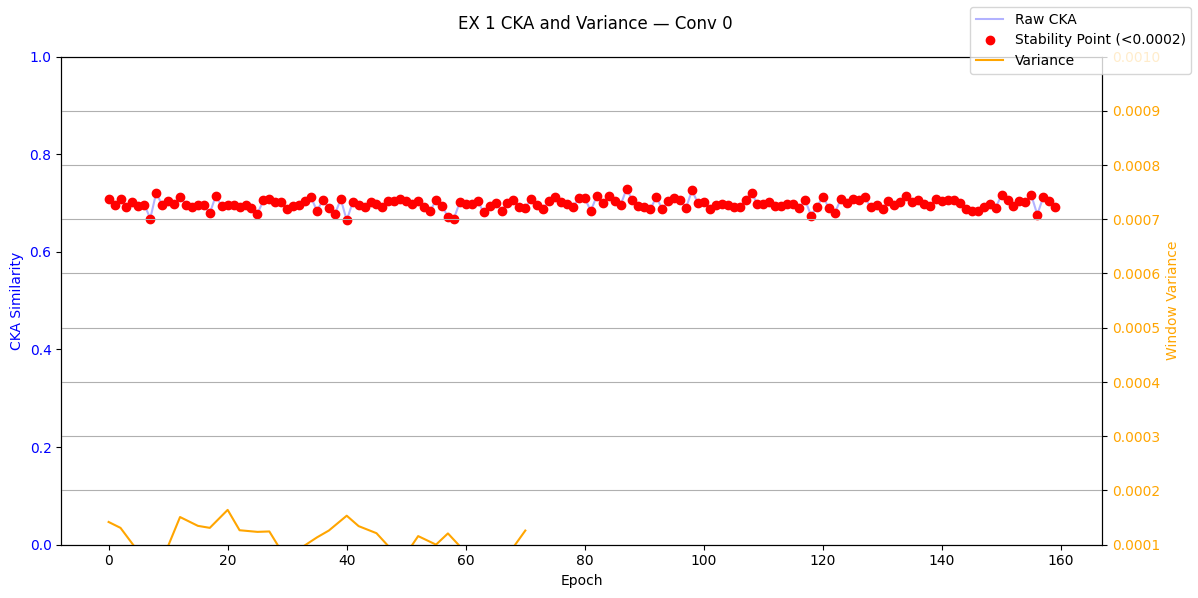

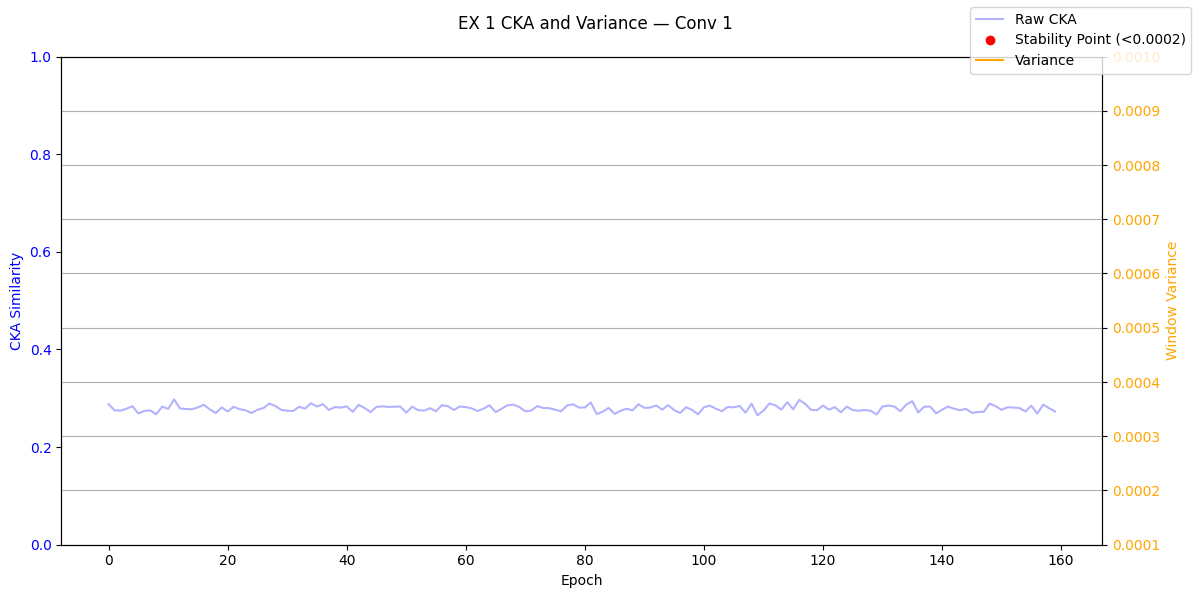

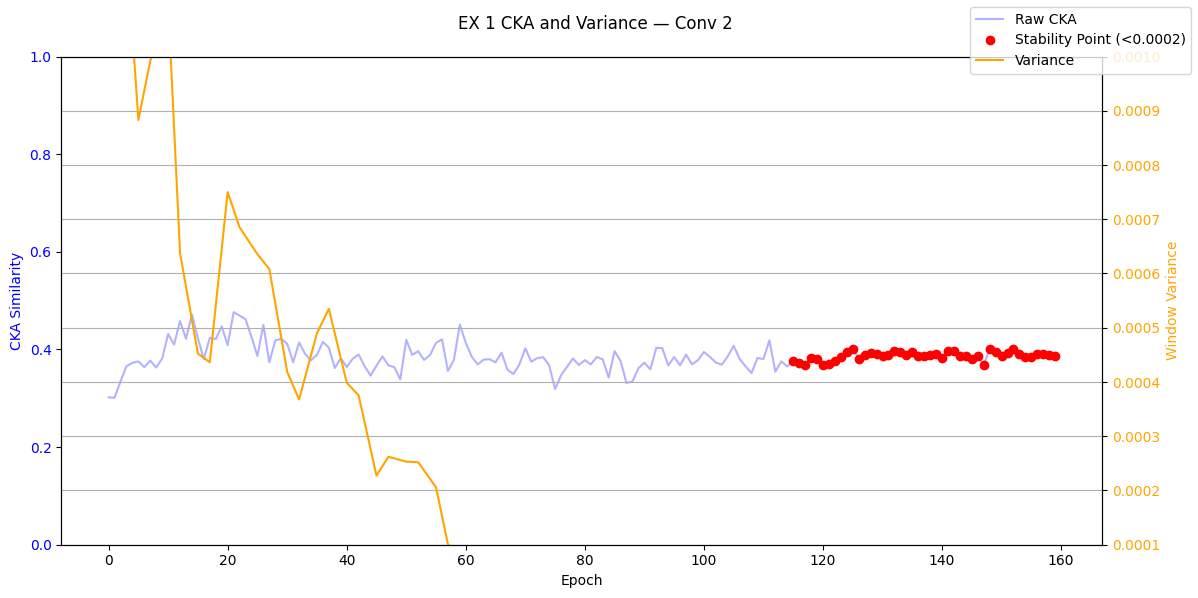

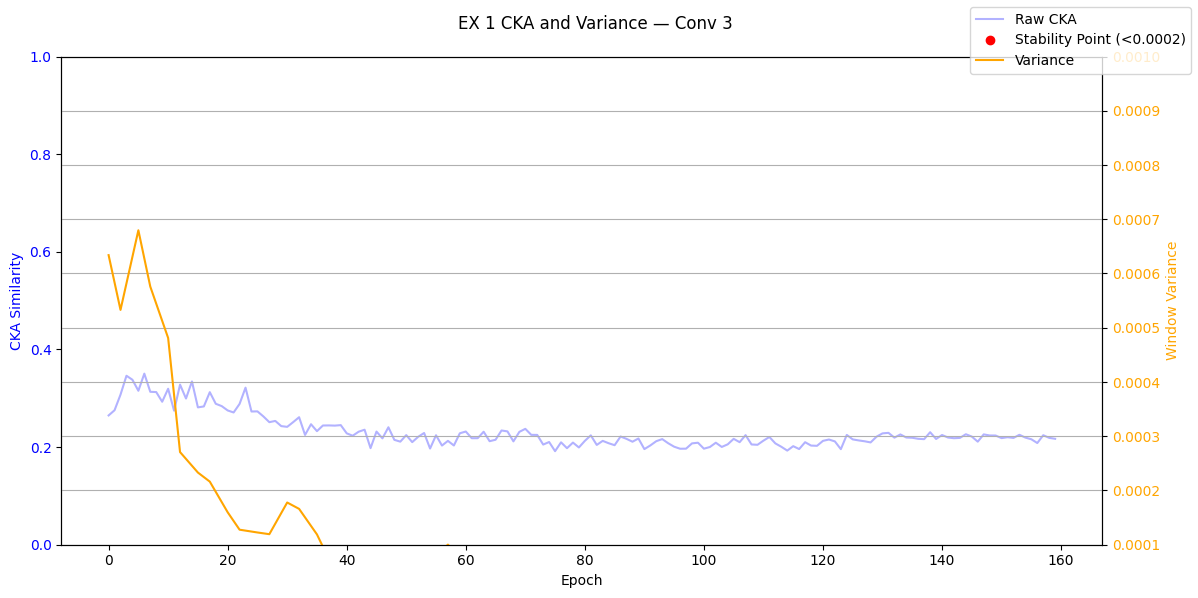

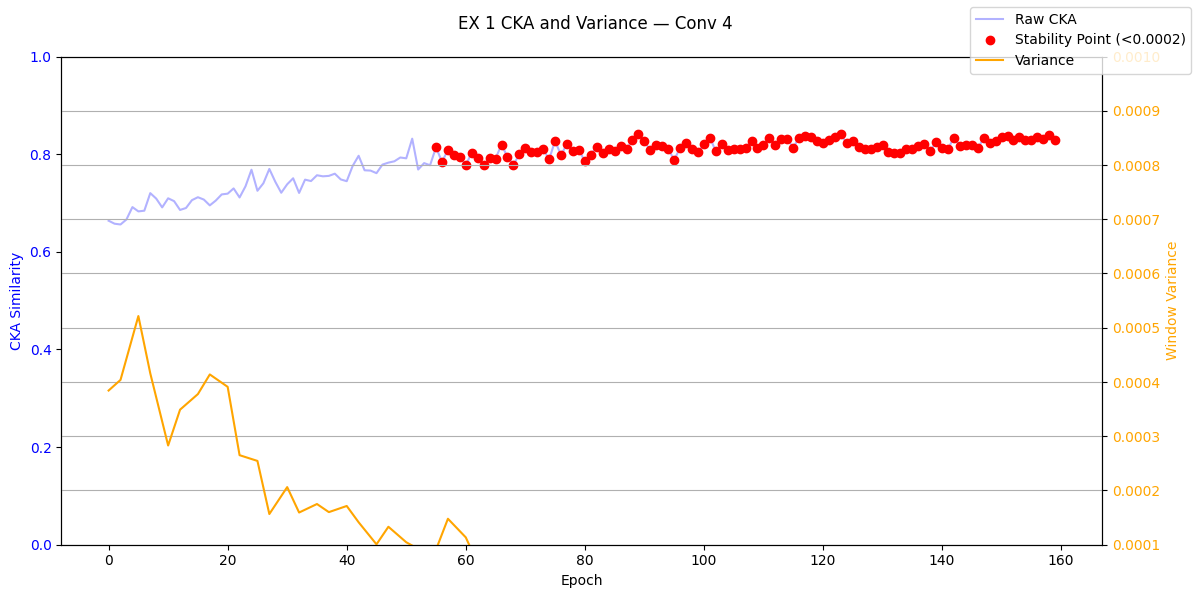

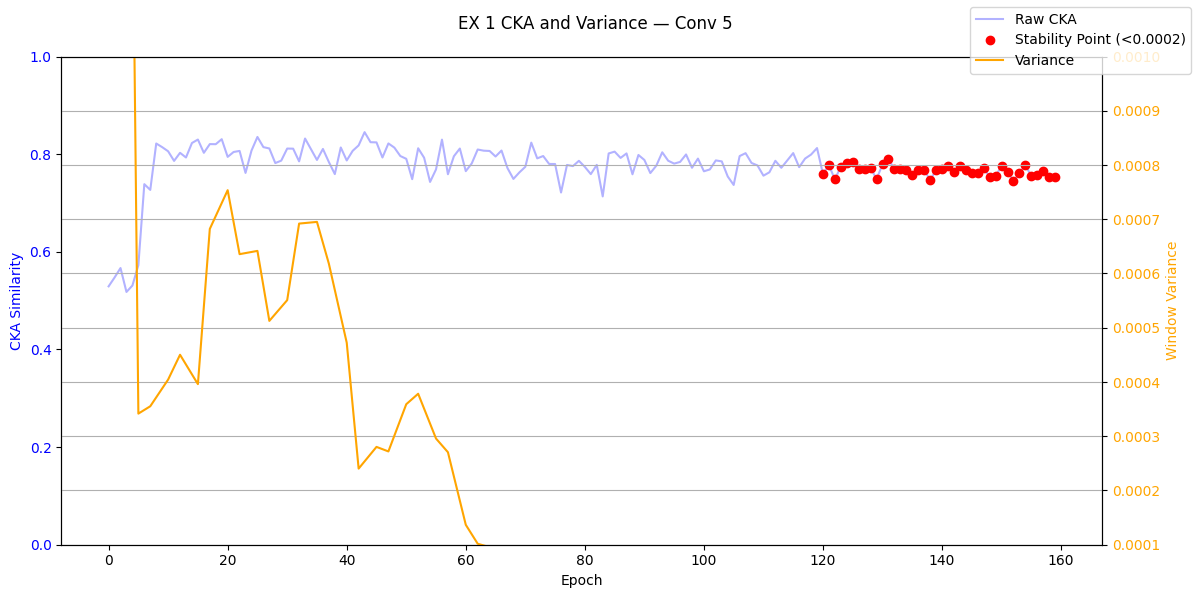

GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER
GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER


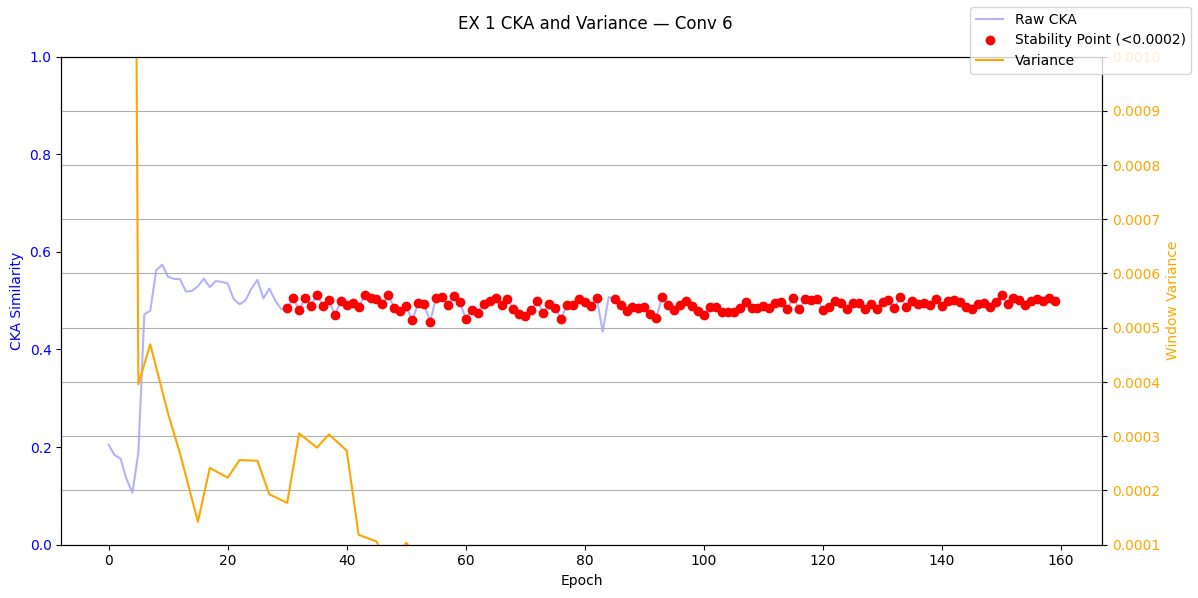

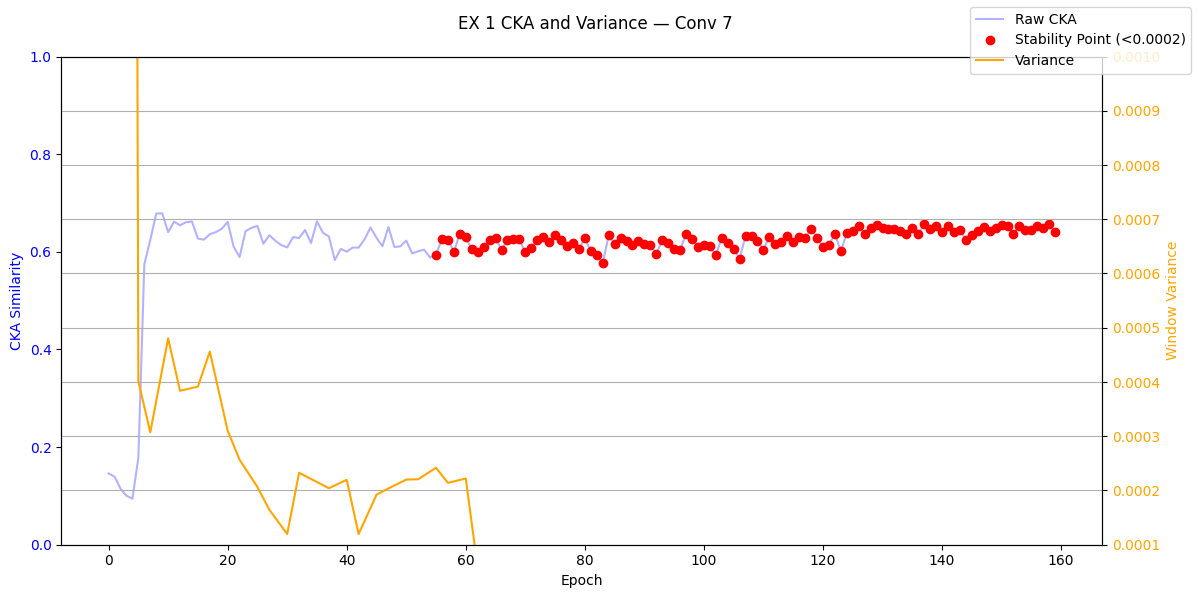

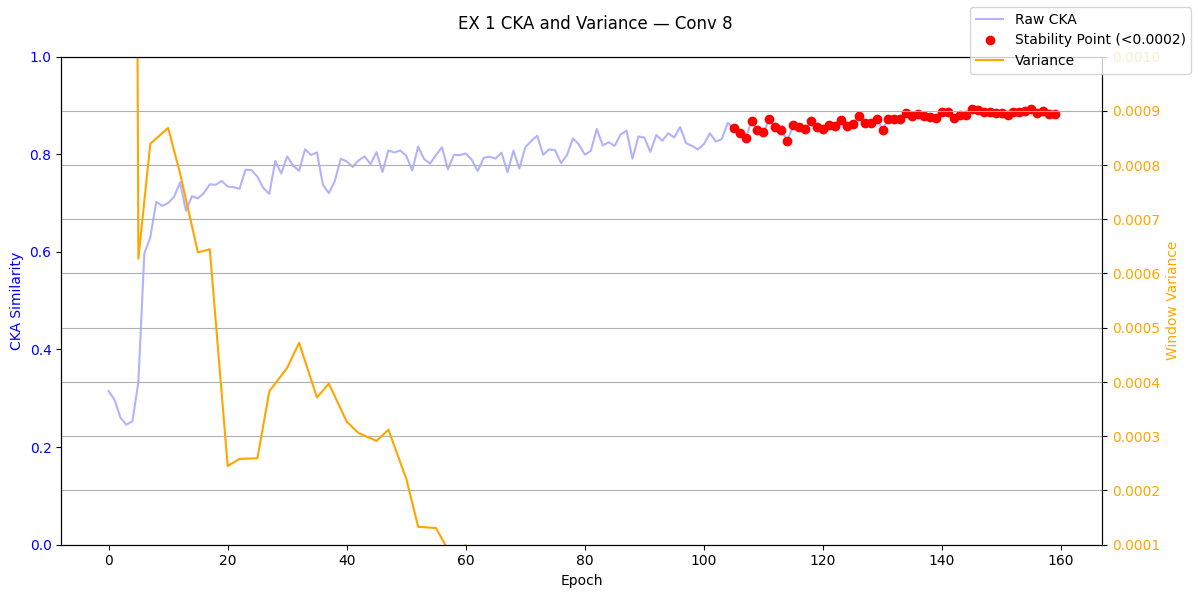

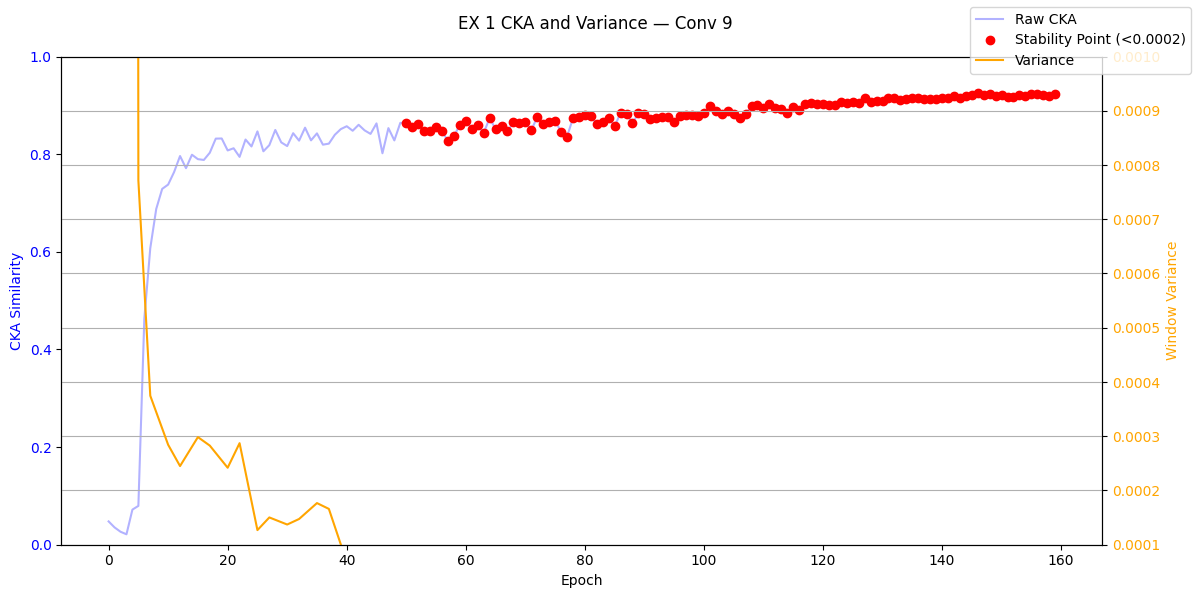

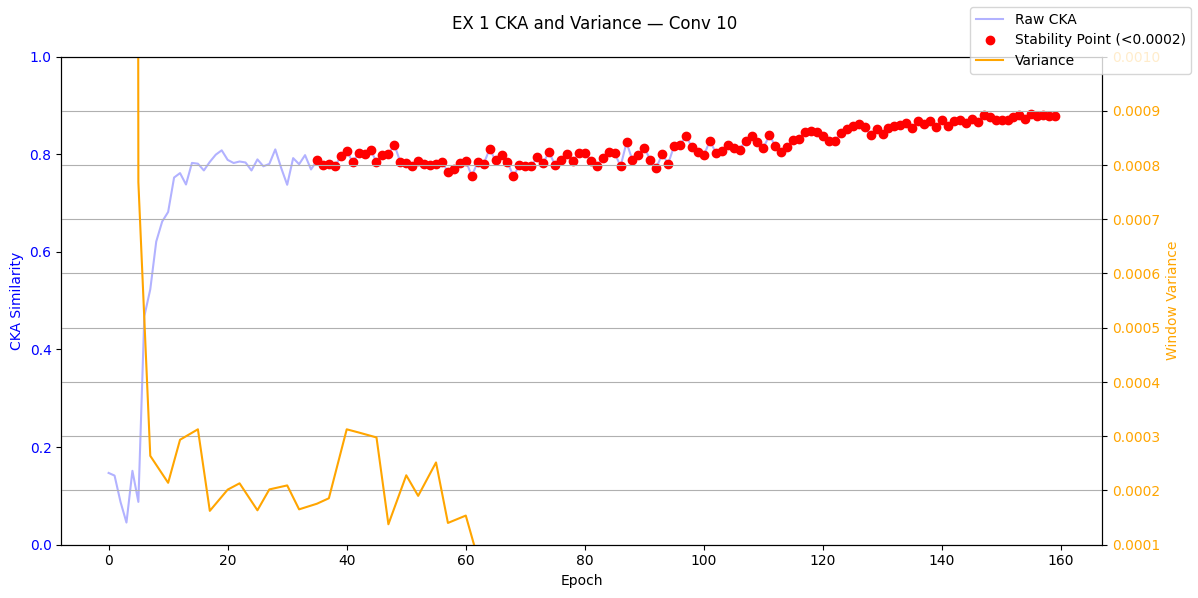

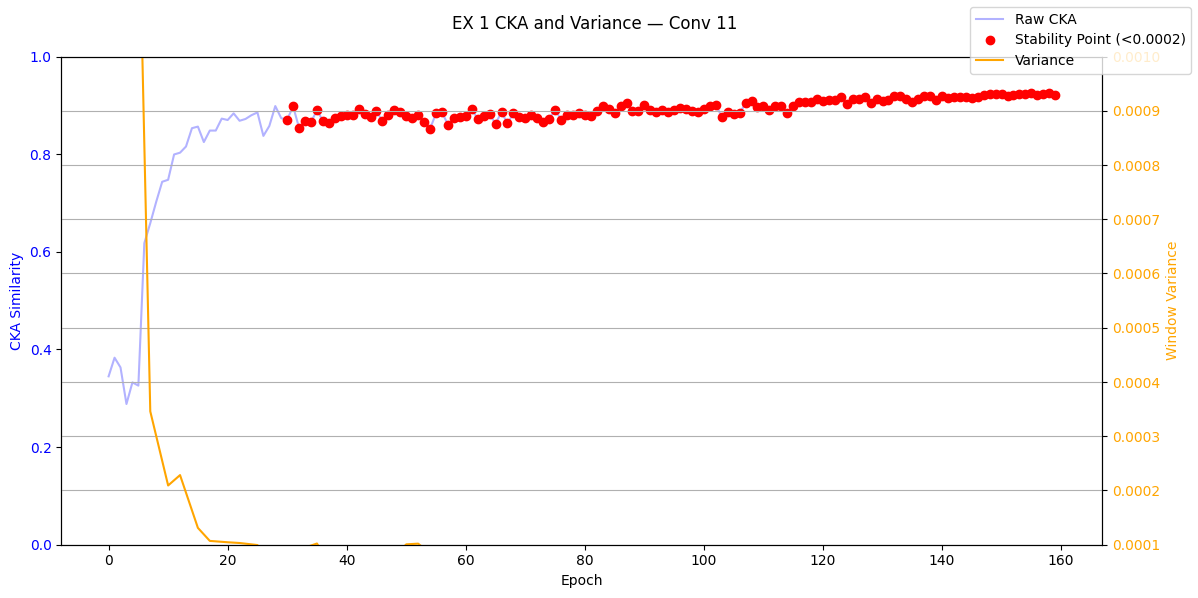

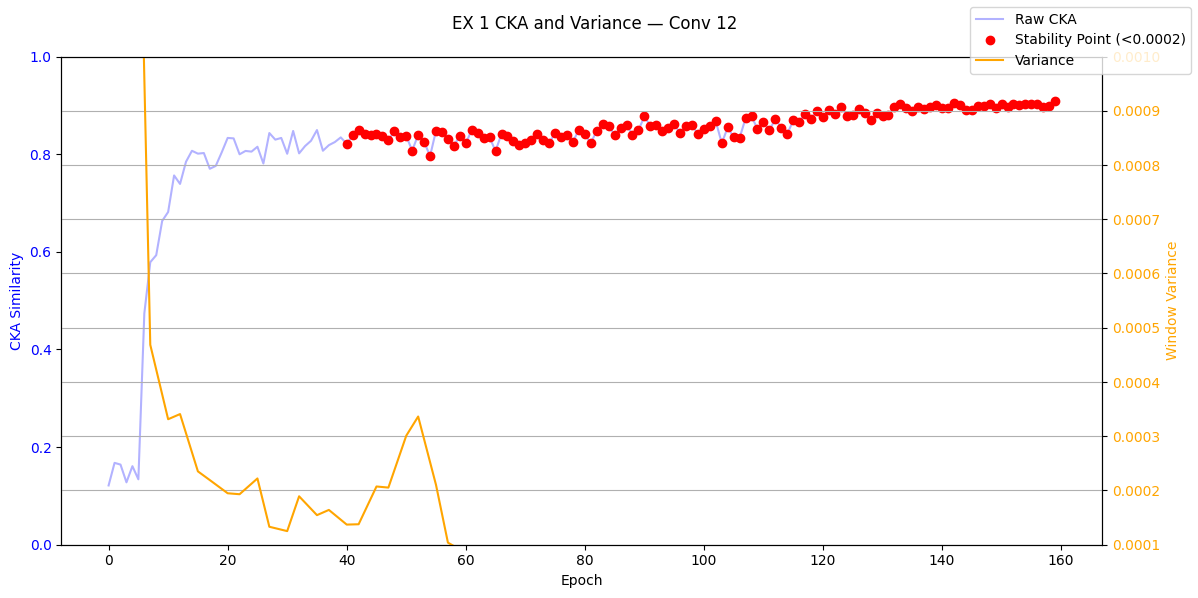

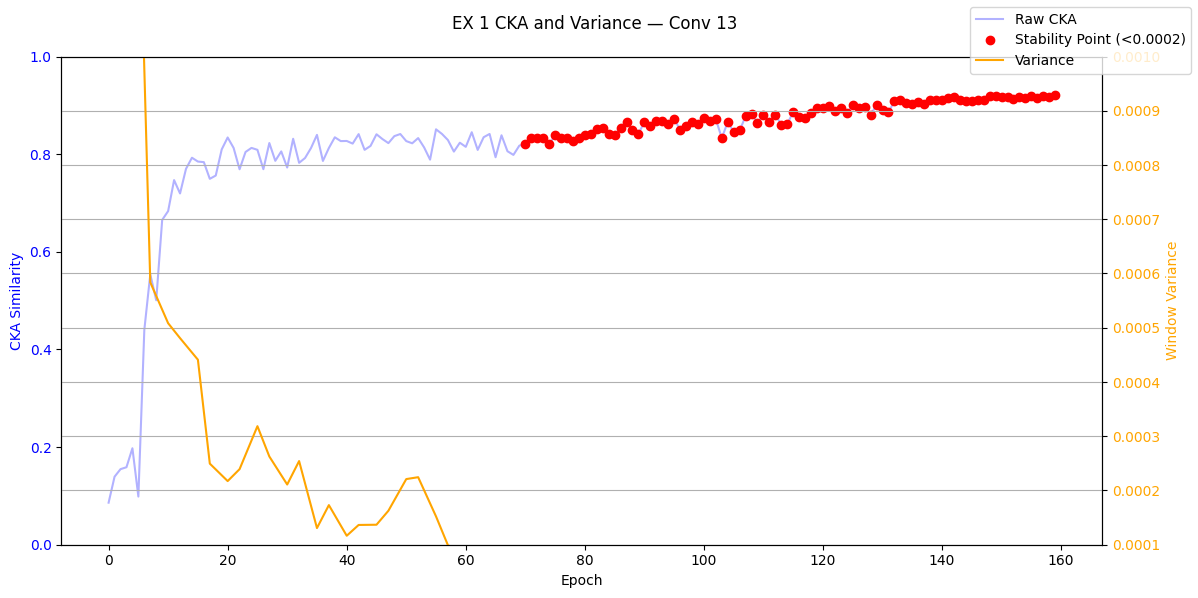

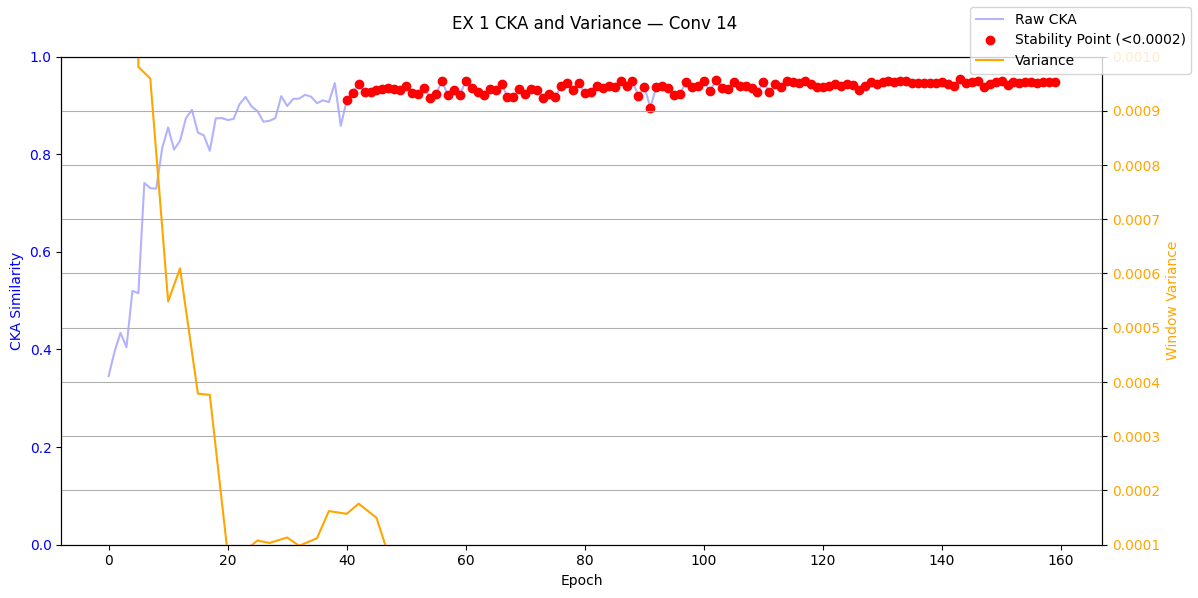

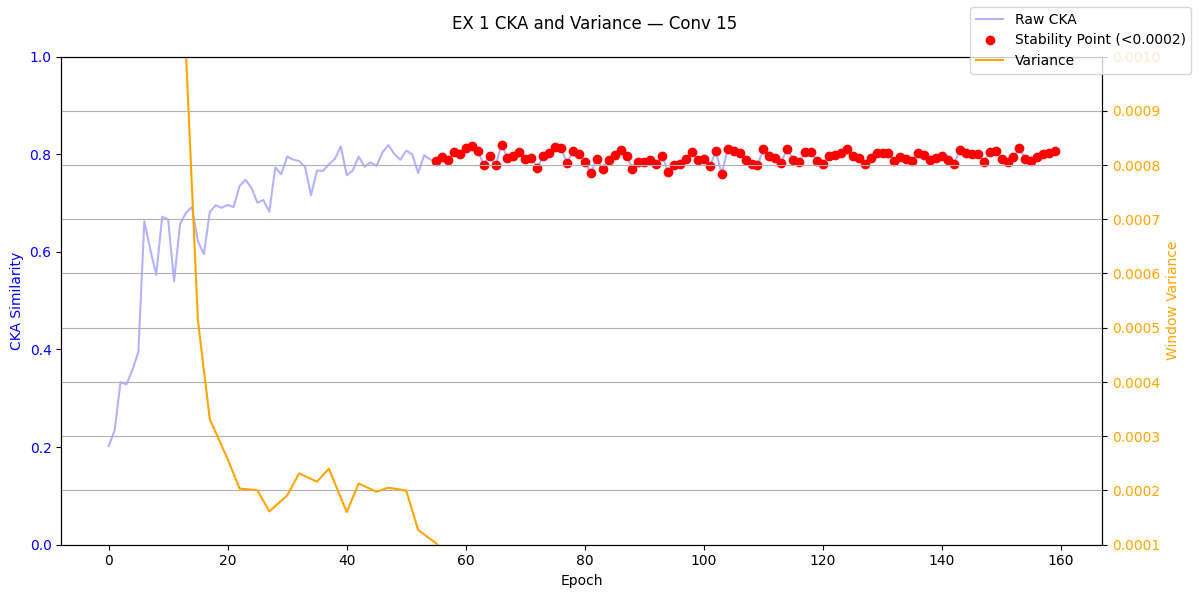

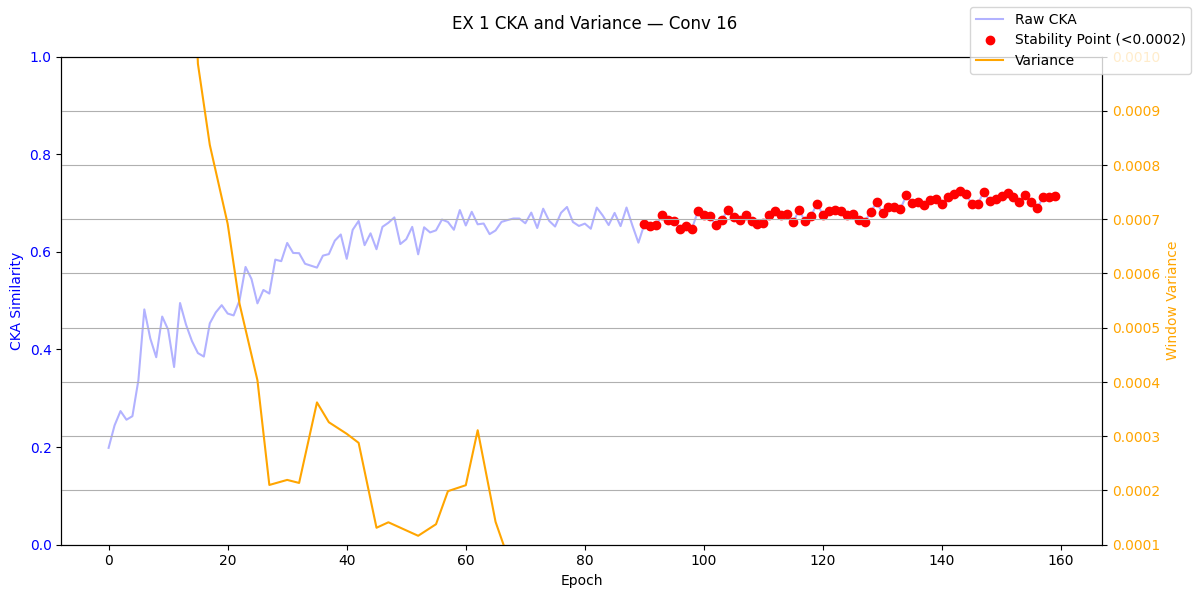

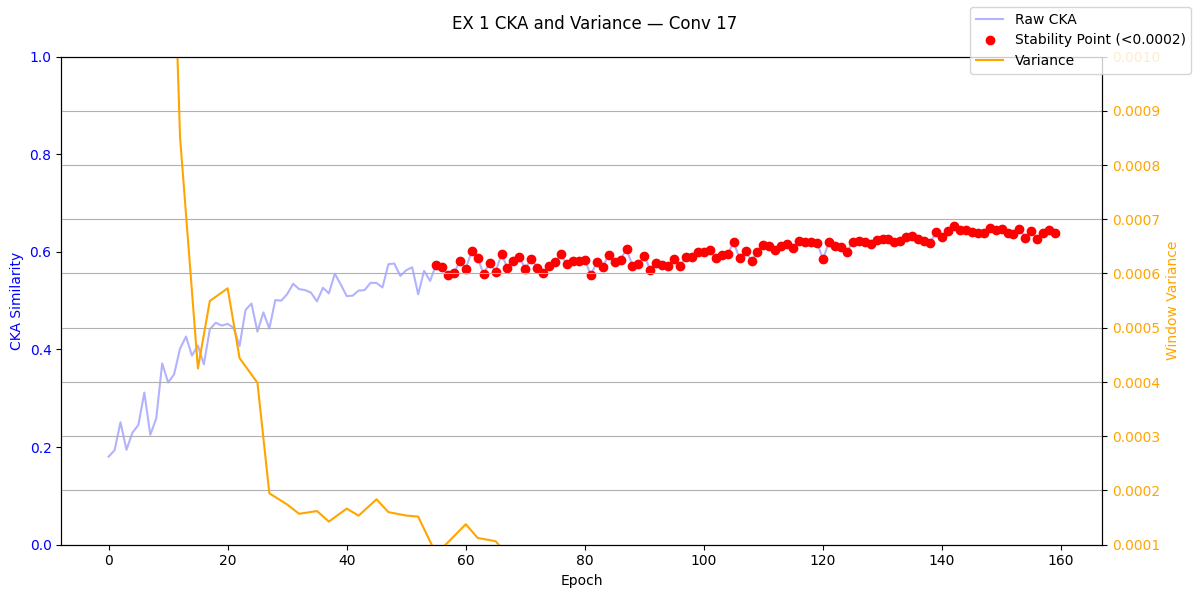

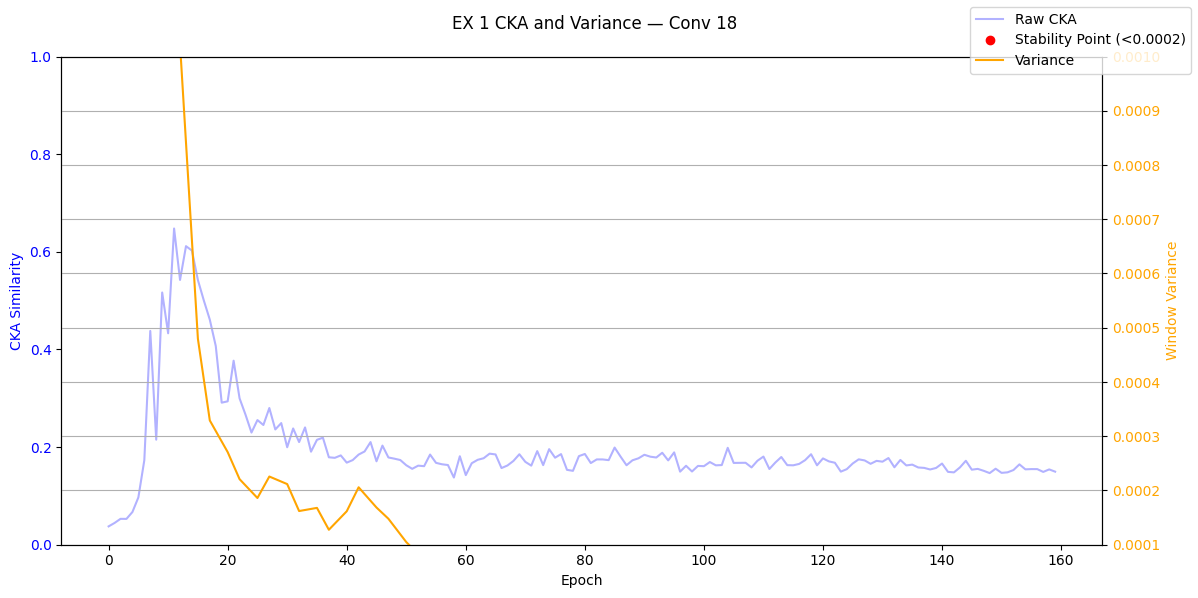

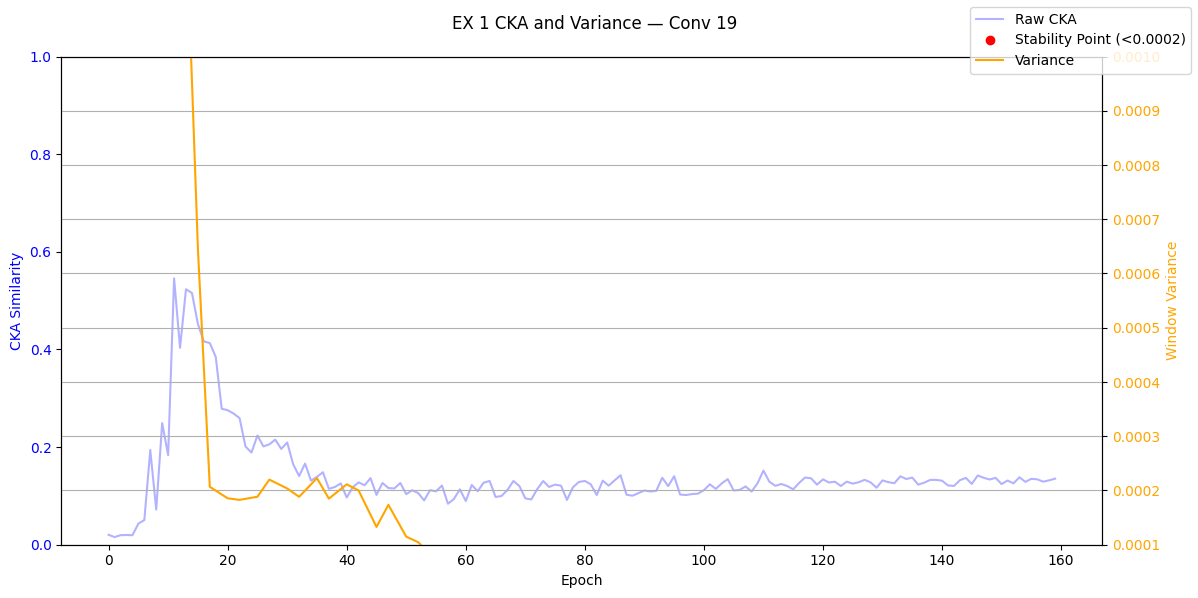

In [5]:
import numpy as np
import matplotlib.pyplot as plt
def get_all_stability_points_for_all_layers(
    all_epochs_matrix, conv_indices, moving_window=20, stride=5, stability_threshold=0.0002, layers=None
):
    if layers is not None:
      cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    cka_freeze_configuration[layers[conv_idx]][-moving_window:] = [1] * moving_window # replace last moving_window elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < 0.1:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print("GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        if frz_moment is not None:
            ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')

        fig.suptitle(f'EX 1 CKA and Variance — Conv {conv_idx}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    if layers is not None:
      return cka_freeze_configuration
with open(f"{experiment}/seed_{experiment_seed}/cka_freeze_layer_decisions.pkl", "rb") as f:
    cka_freeze_layer_decisions = pickle.load(f)
layers = list(cka_freeze_layer_decisions.keys())
cka_freeze_layer_configuration = get_all_stability_points_for_all_layers(all_epochs_matrix, conv_indices=[i for i in range(20)], layers=layers) 

In [6]:
print(cka_freeze_layer_configuration)

{'conv1': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'layer1.0.conv1': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'layer1.

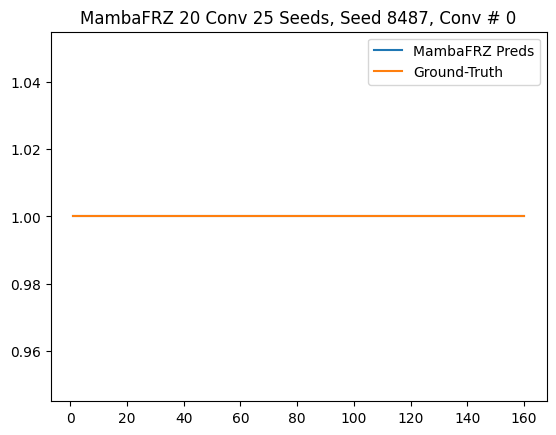

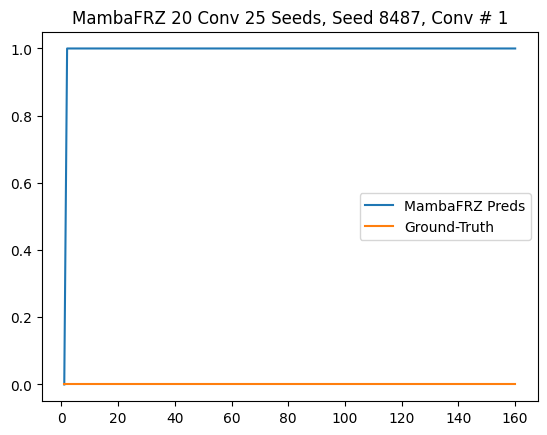

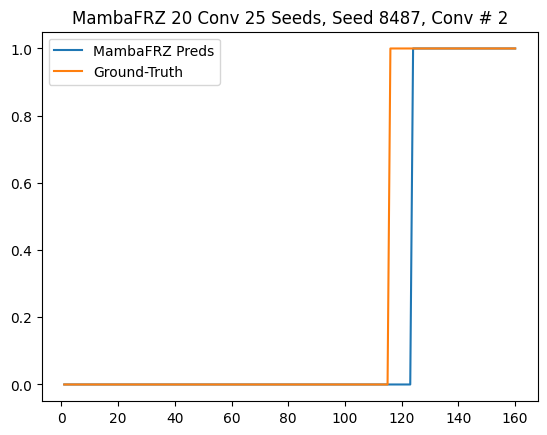

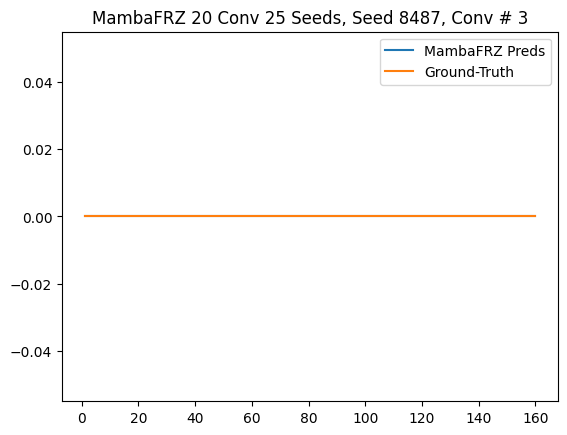

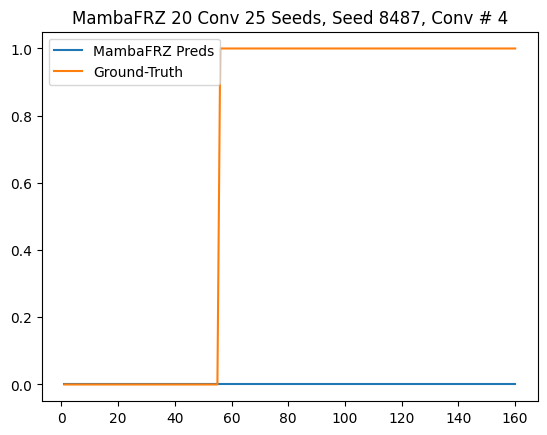

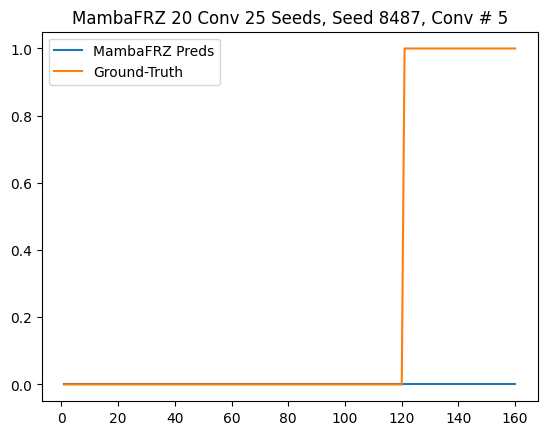

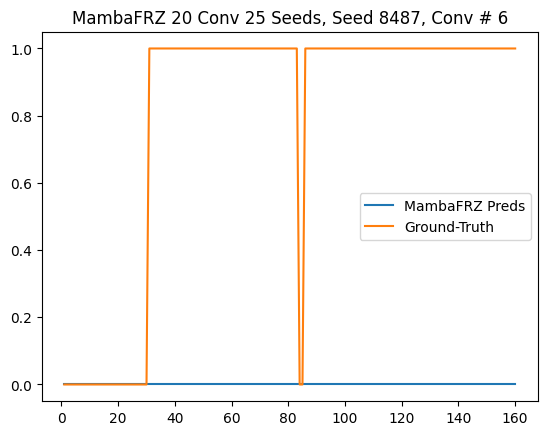

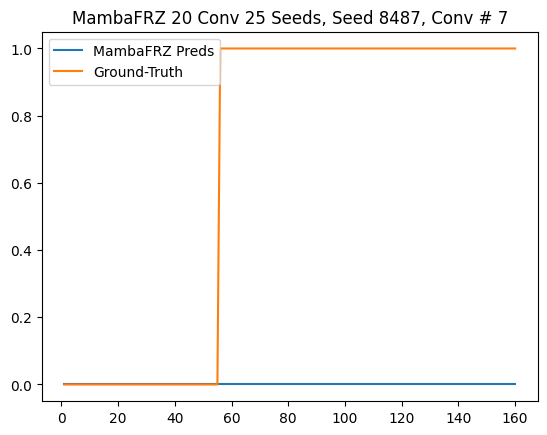

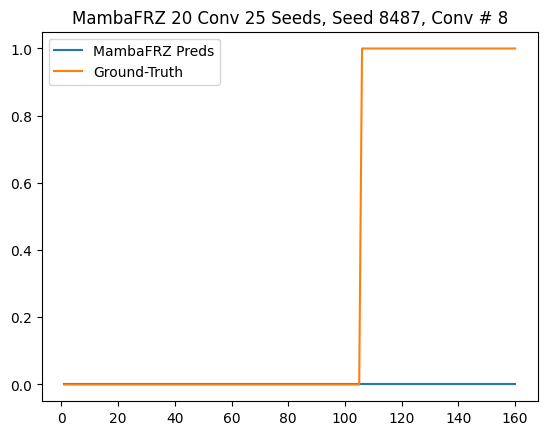

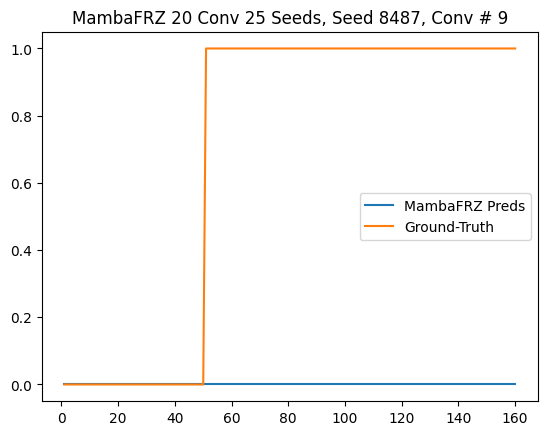

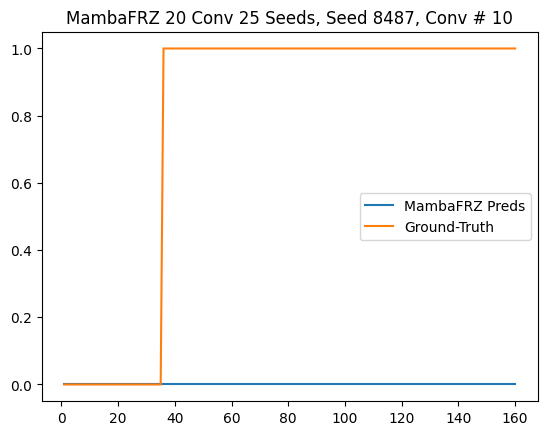

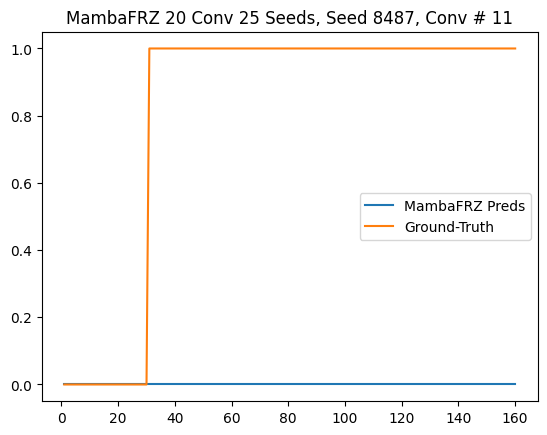

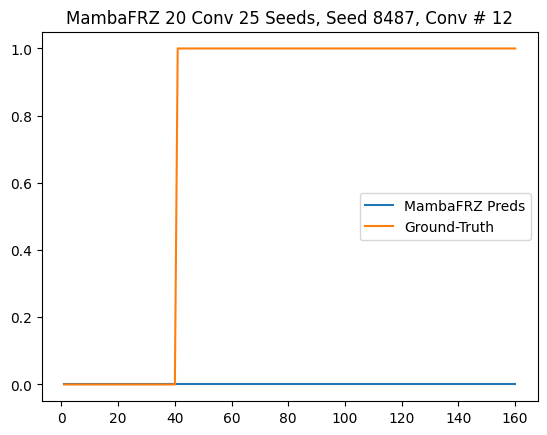

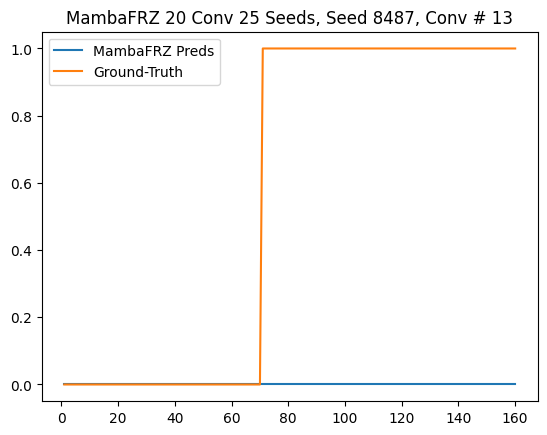

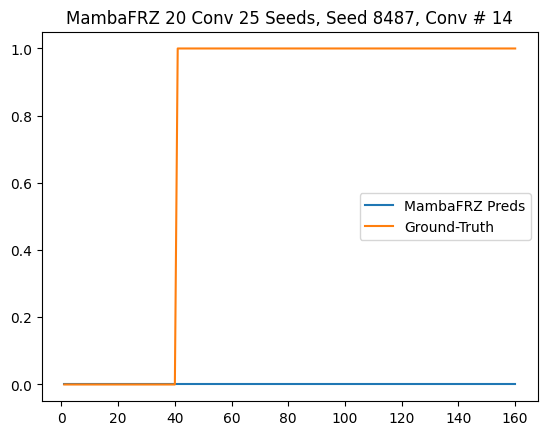

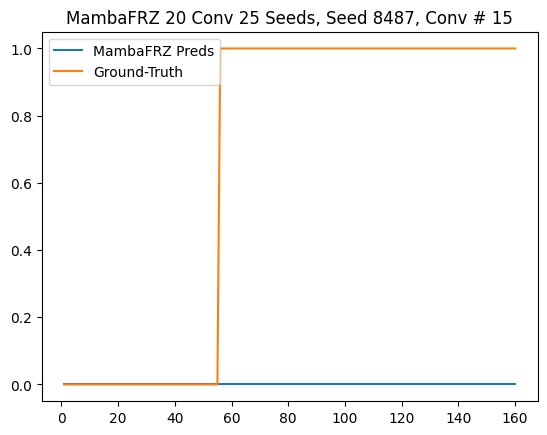

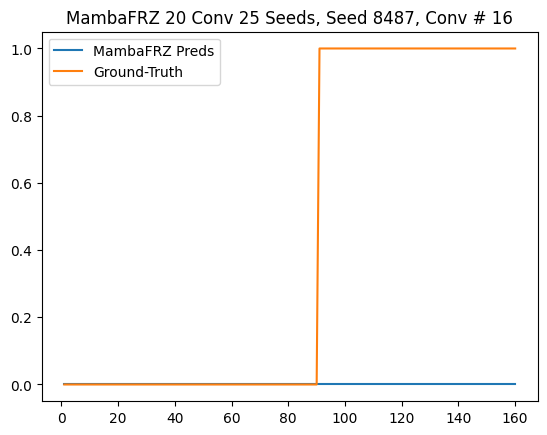

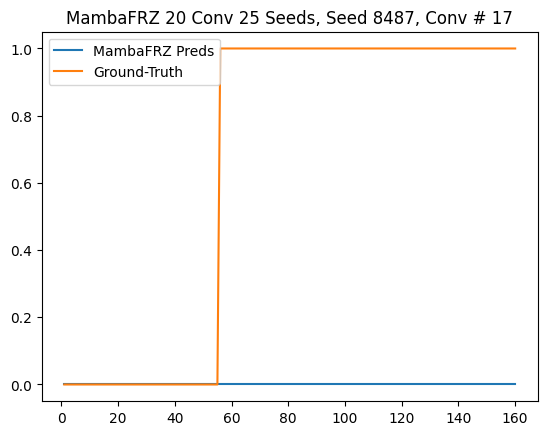

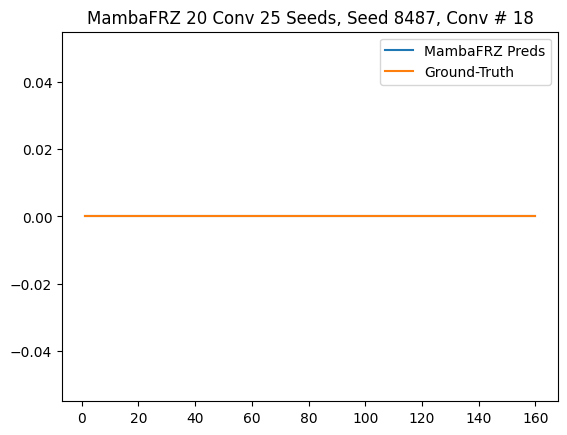

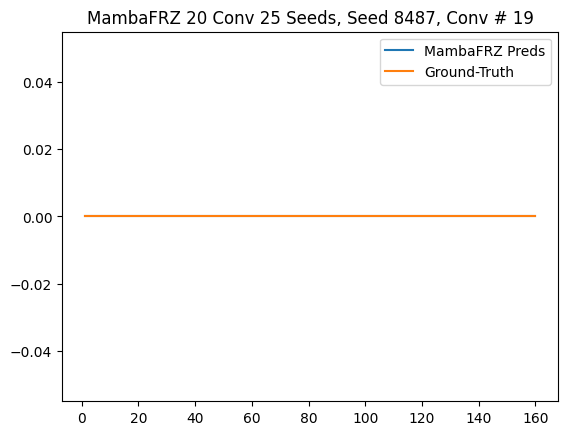

ValueError: x and y must have same first dimension, but have shapes (160,) and (0,)

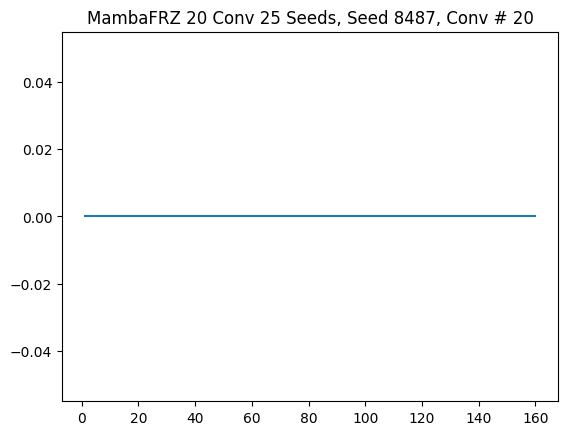

In [7]:
with open(f"{experiment}/seed_{experiment_seed}/frz_predictor_track_conv_frozen.pkl", "rb") as f:
    track_conv_frozen_frz_pred_experiment = pickle.load(f)
for layer_index in track_conv_frozen_frz_pred_experiment.keys():
    layer_info = track_conv_frozen_frz_pred_experiment[layer_index]
    layer_name = layer_info[0]
    mambafrz_preds = layer_info[1]
    mambafrz_preds = layer_info[1] + [layer_info[1][-1]] * (160 - len(mambafrz_preds))
    actual_preds = cka_freeze_layer_configuration[layer_name] if layer_name in cka_freeze_layer_configuration.keys() else None
    if actual_preds == None:
        continue
    epochs = np.arange(1, len(mambafrz_preds) + 1)
    plt.title(f"{experiment_name}, Seed {experiment_seed}, Conv # {layer_index}")
    plt.plot(epochs, mambafrz_preds, label="MambaFRZ Preds")
    plt.plot(epochs, actual_preds, label="Ground-Truth")
    plt.legend()
    plt.savefig(f"output_conv_{layer_index}.jpg")
    plt.show()

In [18]:
print(track_conv_frozen_frz_pred_experiment)

{0: ['conv1', [0, 0, 0, 0, 0, 1]], 1: ['layer1.0.conv1', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], 2: ['layer1.0.conv2', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], 3: ['layer1.0.conv3', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], 4: ['layer1.0.downsample.0', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], 5: ['layer1.1.conv1', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], 6: ['layer1.1.conv2', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], 7: ['layer1.1.conv3', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

[7, 35, 35, 42, 44, 44, 44, 45, 45, 45, 45, 51, 51, 51, 52, 52, 52, 52, 52, 55, 59, 59, 65, 66, 66, 66, 72, 72, 78, 84, 100, 110, 113, 118, 118, 120, 132, 134, 140, 143, 146, 152, 156, 156, 157, 158, 161, 161, 161, 161, 161, 161, 161]


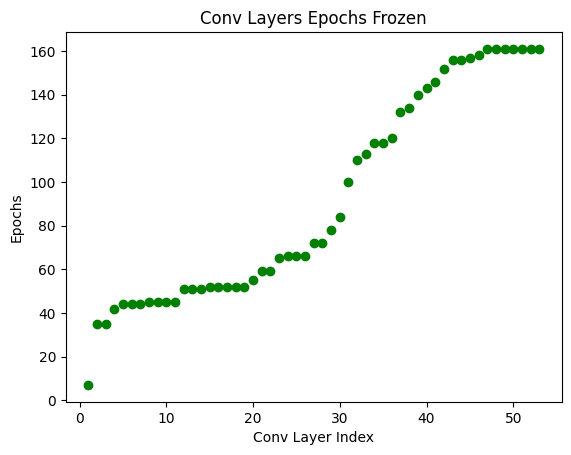

In [19]:
layers = np.arange(1, 54)
epochs_frozen_array = [len(track_conv_frozen_frz_pred_experiment[layer_index-1][1]) + 1 for layer_index in layers]
print(epochs_frozen_array)
plt.title("Conv Layers Epochs Frozen")
plt.xlabel("Conv Layer Index")
plt.ylabel("Epochs")
plt.scatter(layers, epochs_frozen_array, color='green')

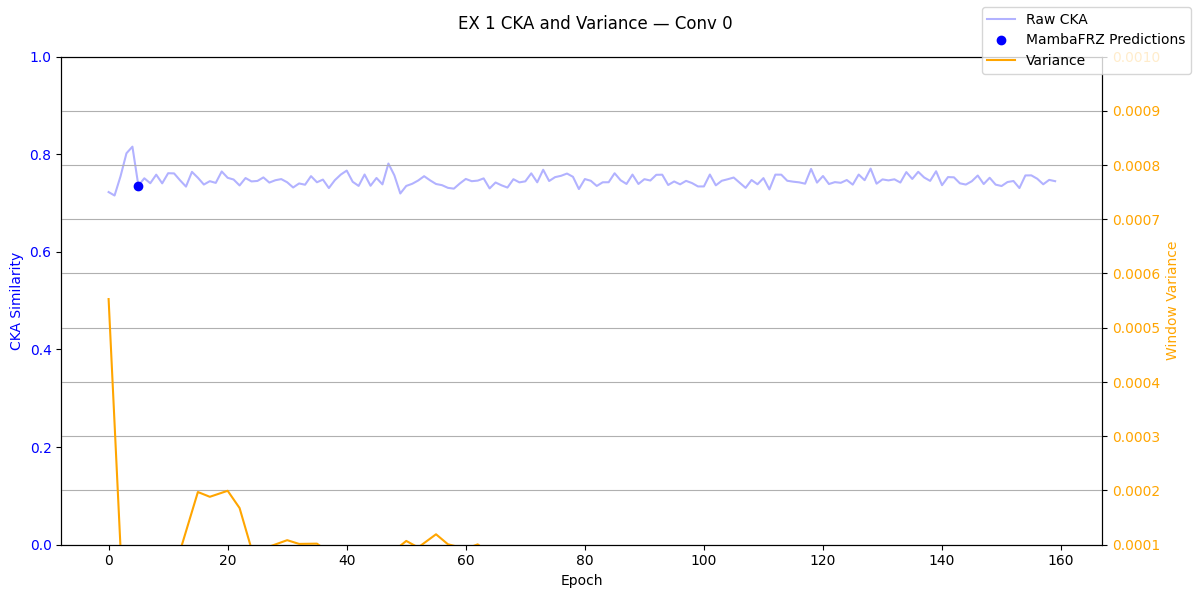

In [11]:
def plot_stability_points_of_all_layers_with_mambafrz_preds(
    all_epochs_matrix, conv_indices, track_conv_frozen_frz_pred=None, moving_window=20, stride=5, stability_threshold=0.0002, layers=None
):
    if layers is not None:
      cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    cka_freeze_configuration[layers[conv_idx]][-moving_window:] = [1] * moving_window # replace last moving_window elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < 0.1:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print("GREATER THAN 3% CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        
        # Plot the predictions by MambaFRZ
        frz_moment_2 = [epoch_index for epoch_index, frz_decision in enumerate(track_conv_frozen_frz_pred[conv_idx][1]) if frz_decision == 1]
        cka_val_at_frz_moment_2 = [cka_vals[epoch_index] for epoch_index in frz_moment_2]
        
        # if frz_moment is not None:
        #     ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')
        
        if frz_moment_2 is not None:
            ax1.plot(frz_moment_2, cka_val_at_frz_moment_2, 'bo', label=f"MambaFRZ Predictions")

        fig.suptitle(f'EX 1 CKA and Variance — Conv {conv_idx}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    if layers is not None:
      return cka_freeze_configuration
with open(f"{experiment}/seed_{experiment_seed}/cka_freeze_layer_decisions.pkl", "rb") as f:
    cka_freeze_layer_decisions = pickle.load(f)
layers = list(cka_freeze_layer_decisions.keys())
cka_freeze_layer_configuration = plot_stability_points_of_all_layers_with_mambafrz_preds(all_epochs_matrix, conv_indices=[i for i in range(1)], layers=layers, track_conv_frozen_frz_pred=track_conv_frozen_frz_pred_experiment) 